In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from physics_equations import specific_humidity_from_rh
import profiles_and_cloud_heights as profiles
import interpolation_lcl as interp
from constants import epsilon, A_1,alpha,g,R_dry
import updraft_emmanuel
from autoconversion_rate import thresh
import autoconversion_rate as ar
from GB84_eqs import f as flux, rho_m
from updraft_emmanuel import w_parcel 
import new_rainfall_scheme as nr
import top_outflow as outflow


c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Loading the Data

In [2]:
#load the datasets -radiometer profiles

cabauw_2 = xr.open_mfdataset(r'..\data\Cabaw_multi_radiometer\*.nc')

#load surface data (cesar network)

cabauw_surface = xr.open_mfdataset(r'..\data\Cabauw_cesar_surface\cesar_surface_meteo_lc1_t10_v1.0_202407.nc')

In [3]:
#choose time period of runs
slice_str = "2024-07-14 00:00:00, 2024-07-14 23:59:00"

In [4]:
slice_tuple = tuple(slice_str.split(", "))
time = cabauw_2.sel(time=slice(*slice_tuple)).time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)
cabauw_2 = cabauw_2.sel(time=slice(*slice_tuple))
cabauw_surface = cabauw_surface.sel(time=time,method='nearest')

In [5]:
vars = ['TA002','P0','TD002','RH002']
surface_vars = cabauw_surface[vars]

T_surf = surface_vars.TA002
p_surf = surface_vars.P0
T_d = surface_vars.TD002
rh_surf = surface_vars.RH002/100

In [6]:
#combining the datasets so that the first value of each profile corresponds to the surface

cabauw_2 = cabauw_2.assign_coords(height=[2 if h == cabauw_2.height[0] else h for h in cabauw_2.height.values])
radiometer_surface = cabauw_2.height[0]
cabauw_2.temperature.loc[dict(height=radiometer_surface)] = T_surf.values
cabauw_2.relative_humidity.loc[dict(height=radiometer_surface)] = rh_surf.values


#### Parsivel rainfall data

In [7]:
parsivel_1 = xr.open_dataset(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=slice(*slice_tuple))
hourly_avg = rain_rate.resample(time='1H').mean()

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\xarray\groupers.py:490: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


#### Environmental profiles and inputs

In [8]:
my_temp = cabauw_2.temperature.values
Z = cabauw_2.height.values
T_d = T_d.values

In [9]:
#build the pressure profile
p = np.zeros(cabauw_2.height.shape[0])
p[0] = 101325 #Pa

for i in range(1,cabauw_2.height.shape[0]):

    p[i:] = p[0]/np.exp(g*cabauw_2.height[i]/R_dry/np.mean(my_temp[0:i+1]))

In [10]:
RH_env = cabauw_2.relative_humidity.sel(time=slice(*slice_tuple)).values
RH_env[RH_env > 1] = 1
q_v = specific_humidity_from_rh(my_temp, RH_env, p)


## Running the model

### Parcel Profiles

In [11]:
rows = my_temp.shape[0]
cols = my_temp.shape[1]

## empty arrays for storing the meteorological profiles
T_arr = np.zeros(my_temp.shape) #parcel temperature profile (time, height)
p_s = np.zeros(rows)    #cloud base pressure (time)
T_s = np.zeros(rows)    #cloud base temperature (time)
lcl_index = np.zeros(rows) #lcl index (time)

## empty arrays for storing the interpolated profiles (time, height+1)
temp_parcel = np.zeros((rows,cols+1))  # new parcel temperature (time, height+1)
my_temp_new = np.zeros((rows,cols+1))   # new temperature profile (time, height+1)
p_new = np.zeros((rows,cols+1))         # new pressure profile (time, height+1)
q_v_new = np.zeros((rows,cols+1))       # new specific humidity profile (time, height+1)
Z_new = np.zeros((rows,cols+1))         # new height profile (time, height+1)

## empty arrays for storing the outputs
T_v_moist = np.zeros((rows,cols+1))
q_v_parcel = np.zeros((rows,cols+1))
Z_b = np.zeros(rows)


In [12]:
#import profiles_and_cloud_heights as profiles
#import interpolation_lcl as interp

for i in range(0,rows):
    print(i)
    #calculating the profiles
    T_arr[i,:],lcl_index[i],p_s[i],T_s[i] = profiles.Temp_prof(my_temp[i,0],p[0],T_d[i],p)

    #interpolation at the lcl level
    temp_parcel[i], p_new[i], Z_new[i], lcl_index[i], my_temp_new[i], q_v_new[i] = interp.insert_lcl_values(T_arr[i,:],p,Z,int(lcl_index[i]),T_s[i],p_s[i],my_temp[i,:],q_v[i,:])

    #calculating the virtual temperature profile of the parcel
    T_v_moist[i,:],q_v_parcel[i,:] = profiles.T_v(T_d[i],p_new[i,0],p_new[i],temp_parcel[i,:],int(lcl_index[i]))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71


In [13]:
# environmental virtual temperature profile
T_v_env = my_temp_new*(1+0.61*q_v_new)

### Cloud Heights

In [14]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index

for i in range(0,rows):
    flag, lfc_idx = profiles.find_lfc(
        T_v_moist[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0


In [15]:
p_t_value = 30000
T_high = 220

#empty arrays for storing the outputs
Z_c = np.zeros(rows)
Z_t = np.zeros(rows)
p_t = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c[i],Z_t[i],p_t[i] = profiles.cloud_top(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],p_t_value,T_v_moist[i],T_v_env[i],T_high,temp_parcel[i])


### Updraft speed

In [16]:
#import updraft_emmanuel

#empty array for saving updraft velocities
w_parcel_max = np.zeros(rows)

for i in range(0,rows):
    print(i)
    if Z_t[i] == 0:
        top_index = 0
    else:
         top_index = np.argmax((Z_t[i] - Z_new[i]) < 0)

    w_parcel_max[i],CAPE = updraft_emmanuel.w_parcel(p_new[i],T_v_moist[i],T_v_env[i],LFC_index[i,1],p_t[i],top_index)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71


### State calculation and update

In [17]:
#import autoconversion_rate as ar
#from GB84_eqs import f as flux, rho_m
#import top_outflow as outflow

#empty arrays for storing condensation flux and state values
f_arr = np.zeros(rows)
X =np.zeros(rows)


for i in range(0,rows):
    print(i)
    if Z_t[i] == 0:
        top_index = 0
    else:
         top_index = np.argmax((Z_t[i] - Z_new[i]) < 0)

    w_avg = w_parcel_max[i]/2
    rho = rho_m(T_s[i],my_temp[i,min(top_index,cols-1)],p_s[i],p_t[i])

    if w_parcel_max[i] == 0:
        # no convection == no flux
        f_arr[i] = 0
    else:
        f_arr[i] = flux(T_d[i],p_new[i,0],p_t[i],my_temp[i,min(top_index,cols-1)],rho,w_avg)

    if i<rows-1:
        if X[i]/Z_c[i] > 2.5e-3:        #capping the X values so that they don't abnormally high
            X[i] = 2.5e-3*Z_c[i]

    #state update
        X[i+1] = X[i] +f_arr[i]*dt_seconds[i] - ar.autoconoversion_rate(X[i],Z_c[i],thresh)*dt_seconds[i] - outflow.O_t(X[i],top_index,Z_b[i],Z_new[i],w_parcel_max[i],int(LFC_index[i,1]),dt_seconds[i])*dt_seconds[i]
        X[i+1] = max(0,X[i+1])


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
2
20
2
21
2
22
2
23
2
24
2
25
2
26
2
27
2
28
2
29
2
30
2
31
2
32
2
33
2
34
2
35
2
36
2
37
2
38
2
39
2
40
2
41
2
42
2
43
2
44
2
45
2
46
2
47
2
48
2
49
2
50
2
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71


In [18]:
#import autoconversion_rate as ar
#import new_rainfall_scheme as nr

# empty arrays for storing the rainfall rates and the size distribution parameters

R = np.zeros(rows)  #rainfall rate at the cloud base
P = np.zeros(rows)  #precipitation rate at the surface

lambda_arr = np.zeros(rows)     #slope parameter of Gamma distribution
mu_result_arr = np.zeros(rows)  #shape parameter of Gamma distribution
Dc_arr = np.zeros(rows)         #critical diameter for evaporation


for i in range(0,rows):
    R[i] = ar.autoconoversion_rate(X[i],Z_c[i],thresh)
    if R[i]==0:
        P[i] = 0
    else:
        Lambda_result = nr.solve_lambda_mu_dependent(R[i], alpha, w_parcel_max[i]/2*100)
        mu_result = nr.mu_from_lambda(Lambda_result)
        print(mu_result,Lambda_result)
        D_critical = ar.critical_diameter(my_temp[i,0], p_new[i,0], T_d[i], Z_new[i,int(lcl_index[i])], Z_c[i],w_parcel_max[i]/2*100).calculate_D_c()
        P[i] = nr.precipitation_rate(ar.autoconoversion_rate(X[i],Z_c[i],thresh), mu_result, Lambda_result, D_critical*100,w_parcel_max[i]/2*100,alpha)

0.3164337896438696 19.230014361229724
0.14496310580656435 17.743929352214206
-0.07917749640583227 15.810537501809975
-0.5022016350630765 12.18937598381613
-0.4411873166400857 12.709460384862462
-0.3661918830209099 13.349732687822769
-0.49749438125544154 12.22947423882823
0.2957415510338939 19.050355465557715
-0.24383969260606753 14.39672564622558
-0.26308137460061176 14.231871492052734
0.5921689426130785 21.63268449083146
0.6302327871818492 21.96563080851095
0.5480832241004083 21.247451747942204
0.7476172007718451 22.994358485730334
1.1788377926204558 26.79925652663937
2.674613319362005 40.328392387203685
0.23105122423768987 18.489263673779526
0.7662868159803427 23.158248400819385
0.4131412968989443 20.070862492060826
0.44495711858852327 20.34792416696847
0.25142685709578916 18.665897561240435
0.8291446530695945 23.710597198614913
0.33242042790394755 19.368878661157893
0.5597229161352553 21.349122167405298
1.0398001778075556 25.567976994405505
3.737483066831433 50.28011035822867
9.1819

## Visualizing the outputs

In [19]:
nearest_time = '2024-07-16T11'
selected = time.sel(time=nearest_time, method='nearest')

# Get the index of the nearest time
index_1 = int(time.get_index('time').get_loc(selected.time.values))

nearest_time_2 = '2024-07-18T11'
selected_2 = time.sel(time=nearest_time_2, method='nearest')

# Get the index of the nearest time
index_2 = int(time.get_index('time').get_loc(selected_2.time.values))

#### Virtual Temperature profiles at different times

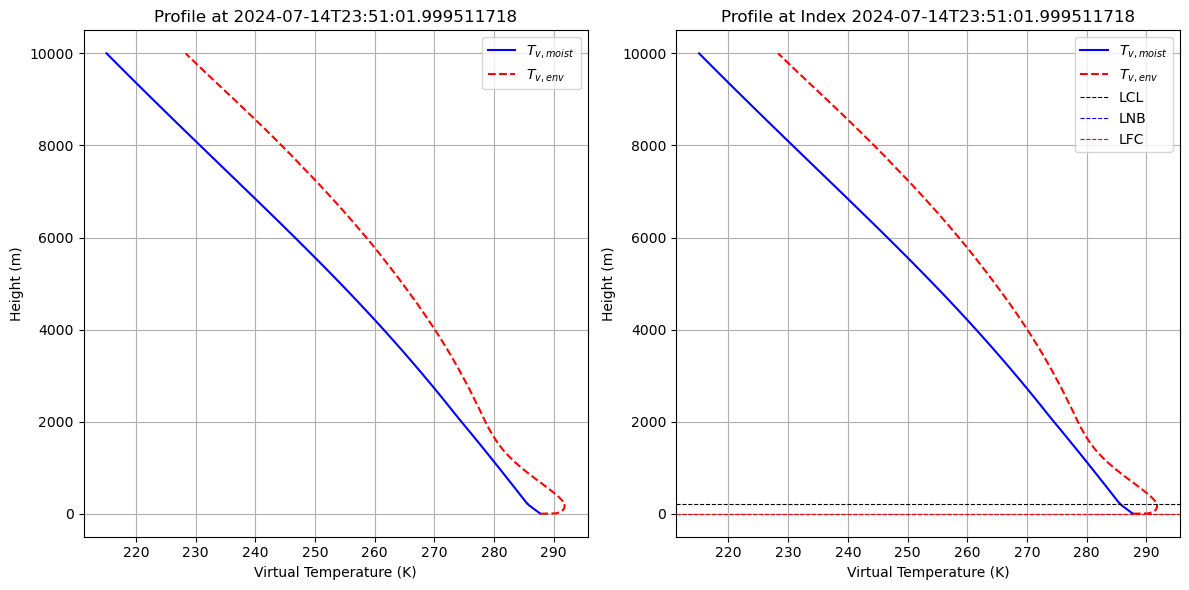

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
index_1 = index_1
index_2 = index_2

# Subplot 1: For index 1
ax1.plot(T_v_moist[index_1], Z_new[index_1], label='$T_{v,moist}$', color='blue')
ax1.plot(my_temp_new[index_1] * (1 + 0.61 * q_v_new[index_1]), Z_new[index_1], 
        label='$T_{v,env}$', color='red', linestyle='--')
ax1.set_xlabel('Virtual Temperature (K)')
ax1.set_ylabel('Height (m)')
ax1.set_title(f'Profile at {time[index_1].values}')
ax1.legend()
ax1.grid(True)

# Subplot 2: For index 2
ax2.plot(T_v_moist[index_2], Z_new[index_2], label='$T_{v,moist}$', color='blue')
ax2.plot(my_temp_new[index_2] * (1 + 0.61 * q_v_new[index_2]), Z_new[index_2], 
        label='$T_{v,env}$', color='red', linestyle='--')
ax2.set_xlabel('Virtual Temperature (K)')
ax2.axhline(y=Z[int(lcl_index[index_2])], color='black', linestyle='--',linewidth='0.8',label='LCL')
ax2.axhline(y=Z_t[index_2], color='blue', linestyle='--',linewidth='0.8',label='LNB')
ax2.axhline(y=Z[int(LFC_index[index_2,1])], color='red', linestyle='--',linewidth='0.8',label='LFC')
ax2.set_xlabel('Virtual Temperature (K)')
ax2.set_ylabel('Height (m)')
ax2.set_title(f'Profile at Index {time[index_2].values}')
ax2.legend()
ax2.grid(True)

plt.tight_layout()  # Prevents overlapping labels
plt.show()
#plt.ylim(Z[lcl_index],Z[LFC_index[1]+2])#,Z[LFC_index[1]+2])
#plt.ylim(0,100#### Cloud top and base0)

#### Cloud top and base

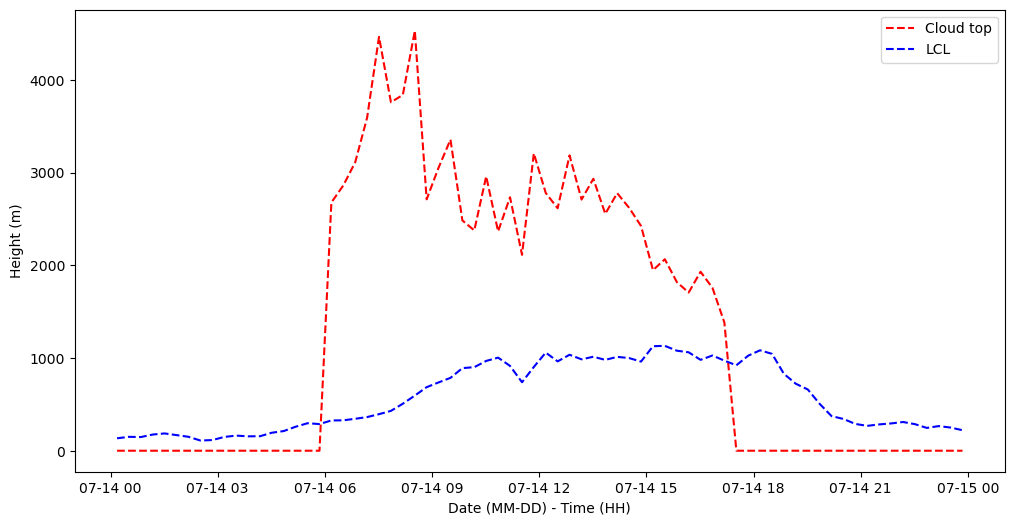

In [21]:
plt.figure(figsize=(12,6))
plt.plot(time,Z_t,color='red',linestyle='--',label='Cloud top')
plt.plot(time,Z_new[np.arange(Z_new.shape[0]),lcl_index.astype(int)],color='blue',linestyle='--',label='LCL')
plt.ylabel('Height (m)')
plt.xlabel('Date (MM-DD) - Time (HH)')
plt.legend()

#### Updraft velocity

Text(0.5, 0, 'Date (MM-DD) - Time (HH)')

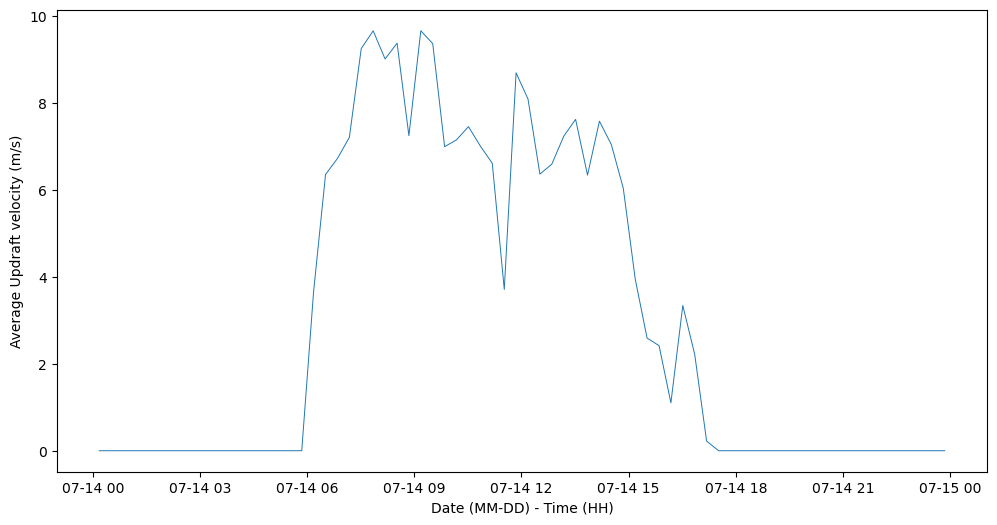

In [22]:
plt.figure(figsize=(12,6))
plt.plot(time,w_parcel_max/2,linewidth=0.7)
plt.ylabel('Average Updraft velocity (m/s)')
plt.xlabel(('Date (MM-DD) - Time (HH)'))

#### LWC and LWP(state)

(0.0, 10.0)

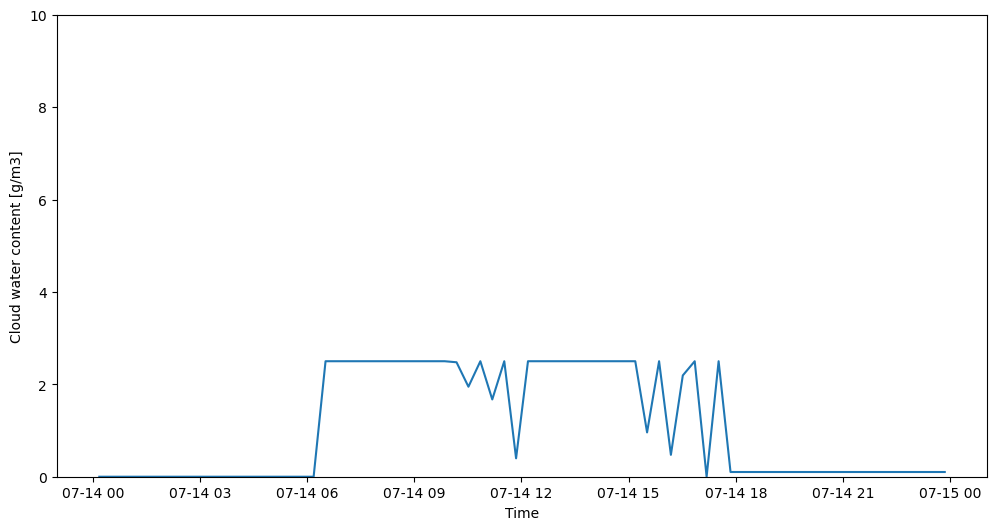

In [23]:
plt.figure(figsize=(12,6))
plt.plot(time,X/Z_c*1000)
plt.ylabel('Cloud water content [g/m3]')
plt.xlabel('Time')
plt.ylim(0,10)

Text(0, 0.5, 'Cloud water content [kg/m2]')

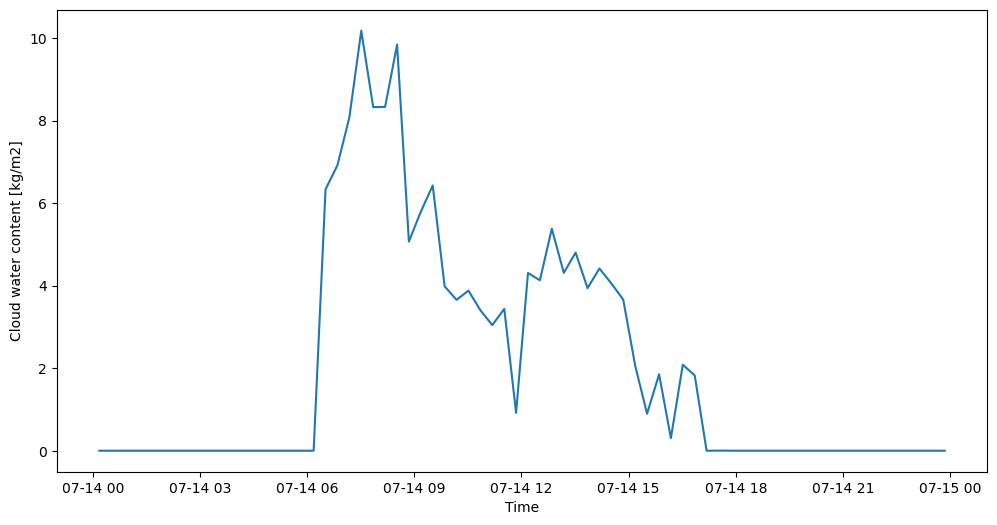

In [24]:
plt.figure(figsize=(12,6))
plt.plot(time,X)
plt.xlabel('Time')
plt.ylabel('Cloud water content [kg/m2]')

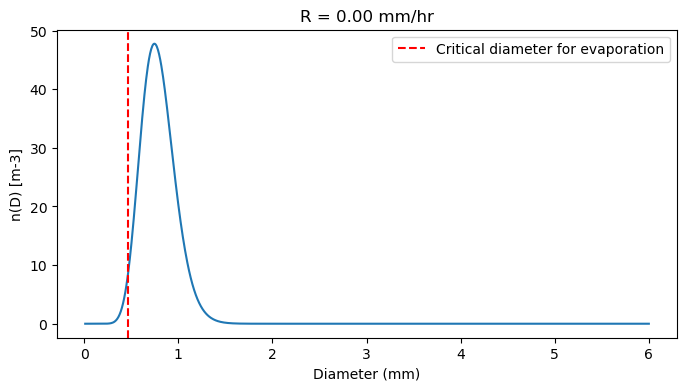

In [25]:
D = np.linspace(0.001,0.6,1000)
N = 6e4 * np.exp(3.2 * mu_result)* D**(mu_result)*np.exp(-Lambda_result*D)#plt.ylim(0,100)

plt.figure(figsize=(8,4))
plt.title(f'R = {R[i] * 3600:.2f} mm/hr')
plt.plot(D*10,N)
plt.axvline(x=D_critical*1000,color='r',linestyle='--',label='Critical diameter for evaporation')
plt.xlabel('Diameter (mm)')
plt.ylabel('n(D) [m-3]')
plt.legend()